# Loading data

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

In [25]:
def importdata():
    balance_data = pd.read_csv("breastcancerdata.csv")
    print("Dataset Length:", len(balance_data))
    print("Dataset Shape:", balance_data.shape)
    print("Dataset Head:\n", balance_data.head())
    return balance_data

In [26]:
data = importdata()
print(data.isnull().sum())

Dataset Length: 569
Dataset Shape: (569, 33)
Dataset Head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

  

# Functions 

In [27]:
def splitdataset(balance_data):
    Y = balance_data["diagnosis"].map({"M": 1, "B": 0}).values
    X = balance_data.drop(columns=["id", "diagnosis"], errors="ignore").values
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=100, stratify=Y)
    return X, Y, X_train, X_test, y_train, y_test

In [28]:
def train_using_gini(X_train, y_train):
    clf_gini = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=3, min_samples_leaf=5)
    clf_gini.fit(X_train, y_train)
    return clf_gini

In [29]:
def train_using_entropy(X_train, y_train):
    clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=3, min_samples_leaf=5)
    clf_entropy.fit(X_train, y_train)
    return clf_entropy

In [30]:
def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Predicted Values:\n", y_pred)
    return y_pred

In [31]:
def cal_accuracy(y_test, y_pred):
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nAccuracy:", accuracy_score(y_test, y_pred) * 100)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [32]:
def plot_decision_tree(clf_object, feature_names, class_names):
    plt.figure(figsize=(15, 10))
    plot_tree(clf_object, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
    plt.show()

# Model training and evaluation

In [33]:
data = importdata()
X, Y, X_train, X_test, y_train, y_test = splitdataset(data)

  
print("\n Training Using Gini ")
clf_gini = train_using_gini(X_train, y_train)
y_pred_gini = prediction(X_test, clf_gini)
cal_accuracy(y_test, y_pred_gini)

    
print("\n Training Using Entropy ")
clf_entropy = train_using_entropy(X_train, y_train)
y_pred_entropy = prediction(X_test, clf_entropy)
cal_accuracy(y_test, y_pred_entropy)

Dataset Length: 569
Dataset Shape: (569, 33)
Dataset Head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

  

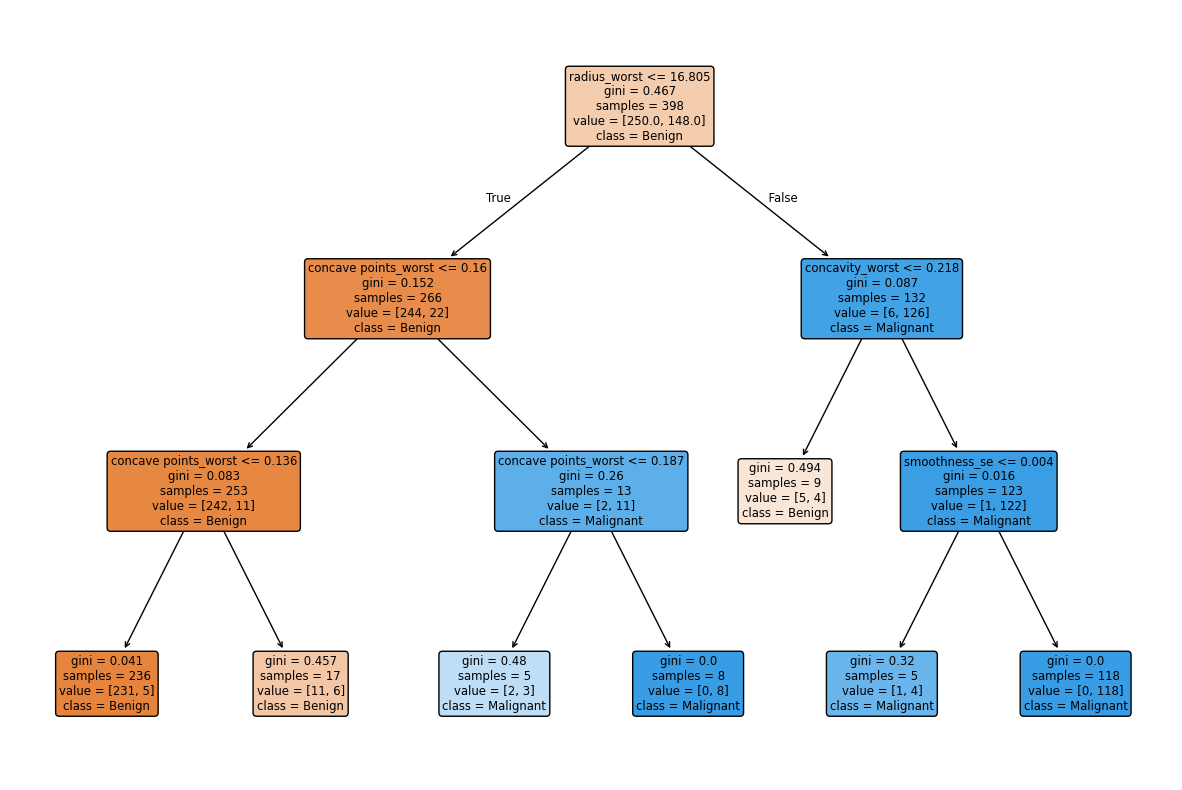

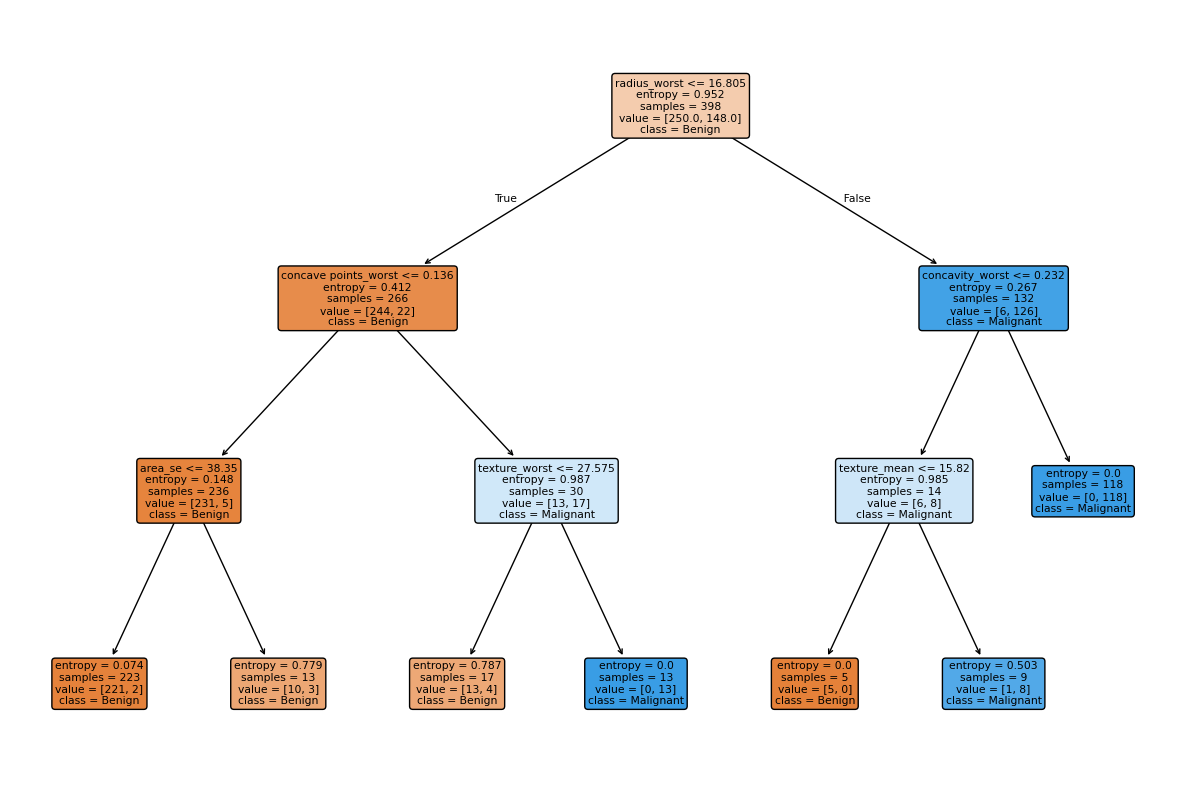

In [34]:
feature_names = data.drop(columns=["id", "diagnosis"], errors="ignore").columns
class_names = ["Benign", "Malignant"]

plot_decision_tree(clf_gini, feature_names, class_names)
plot_decision_tree(clf_entropy, feature_names, class_names)

In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf_gini, X, Y, cv=5, scoring="accuracy")
print("CV accuracies:", scores)
print("Mean CV accuracy:", scores.mean())
print("Std:", scores.std())

CV accuracies: [0.9122807  0.92105263 0.95614035 0.94736842 0.91150442]
Mean CV accuracy: 0.9296693060083838
Std: 0.01855019372409562


In [36]:
scores = cross_val_score(clf_entropy, X, Y, cv=5, scoring="accuracy")
print("CV accuracies:", scores)
print("Mean CV accuracy:", scores.mean())
print("Std:", scores.std()) 


CV accuracies: [0.90350877 0.9122807  0.96491228 0.93859649 0.95575221]
Mean CV accuracy: 0.935010091600683
Std: 0.02385873866710912


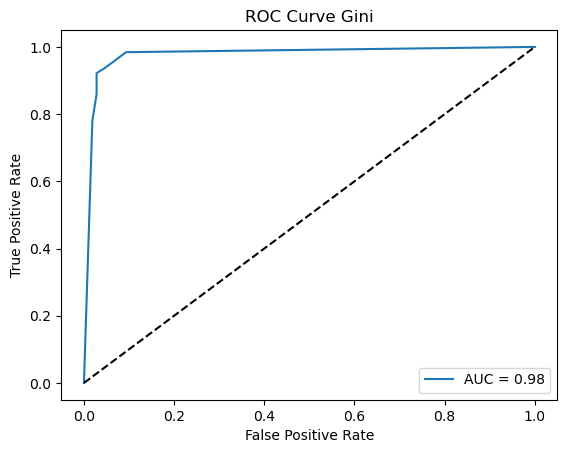

In [37]:
from sklearn.metrics import roc_curve, auc

y_probs = clf_gini.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Gini")
plt.legend()
plt.show()

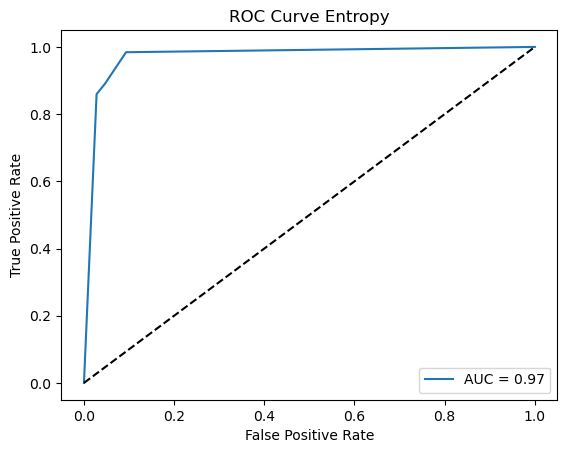

In [38]:
from sklearn.metrics import roc_curve, auc

y_probs = clf_entropy.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Entropy")
plt.legend()
plt.show()

# Most important features gini

In [57]:
feature_names = data.drop(columns=["id", "diagnosis"], errors="ignore").columns

importance = clf_gini.feature_importances_

feat_imp_gini = pd.Series(importance, index=feature_names)
feat_imp_sorted_gini = feat_imp_gini.sort_values(ascending=False)

print(feat_imp_sorted.head(10))

radius_worst               0.838568
concave points_worst       0.127604
concavity_worst            0.031428
smoothness_se              0.002399
radius_mean                0.000000
concavity_se               0.000000
fractal_dimension_worst    0.000000
symmetry_worst             0.000000
compactness_worst          0.000000
smoothness_worst           0.000000
dtype: float64


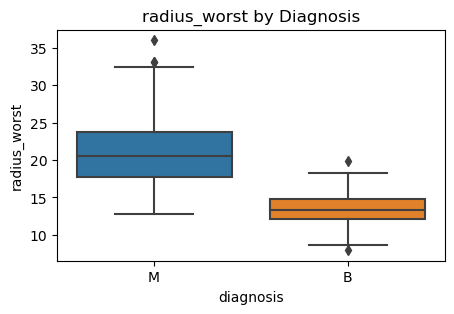

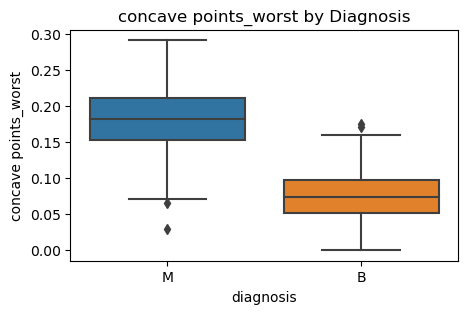

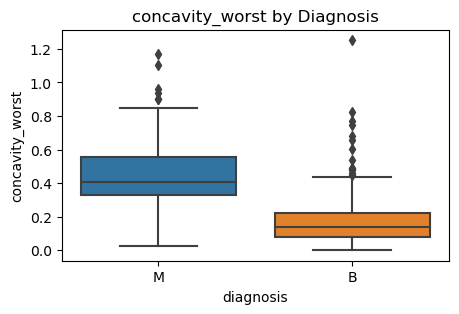

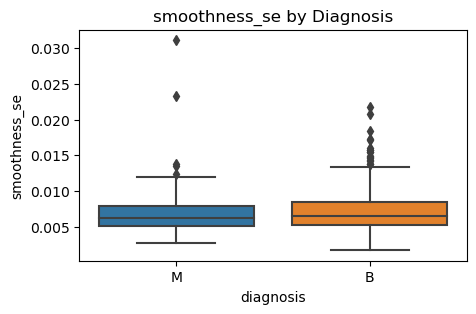

In [61]:
top_features_gini = feat_imp_sorted_gini.head(4).index

for feature in top_features_gini:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="diagnosis", y=feature, data=data)
    plt.title(f"{feature} by Diagnosis")
    plt.show()

# Most important features entropy

In [62]:
feature_names = data.drop(columns=["id","diagnosis"], errors="ignore").columns

importance_entropy = clf_entropy.feature_importances_

feat_imp_entropy = pd.Series(importance_entropy, index=feature_names)
feat_imp_entropy_sorted = feat_imp_entropy.sort_values(ascending=False)

print(feat_imp_entropy_sorted.head(10))

radius_worst               0.700389
concave points_worst       0.134394
concavity_worst            0.064051
texture_worst              0.048541
texture_mean               0.027702
area_se                    0.024922
radius_mean                0.000000
concave points_se          0.000000
fractal_dimension_worst    0.000000
symmetry_worst             0.000000
dtype: float64


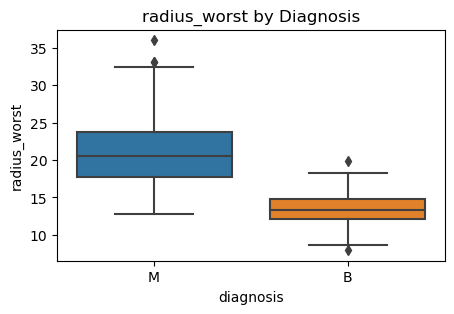

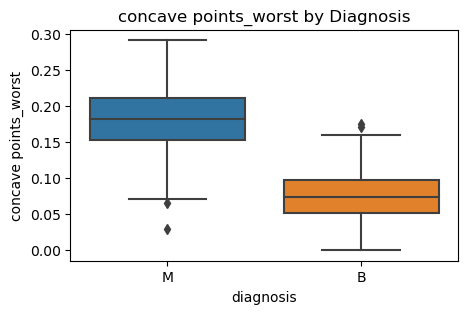

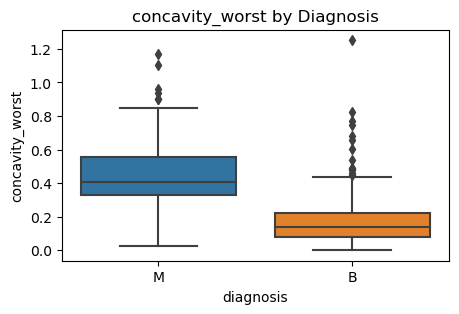

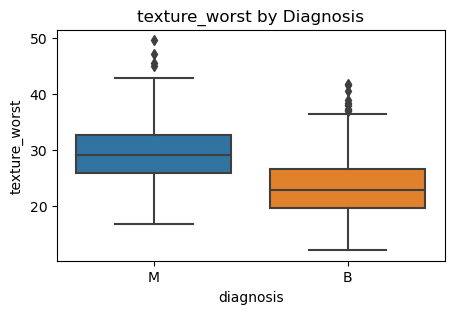

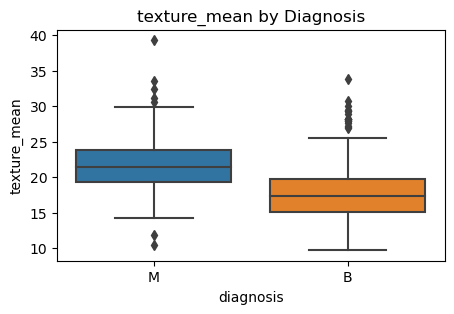

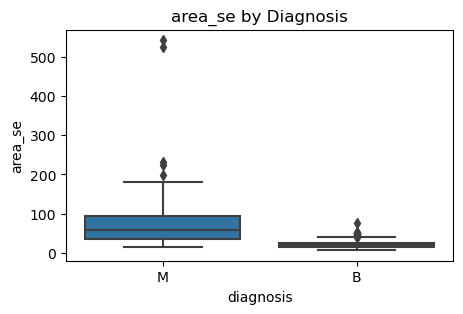

In [63]:
top_features_entropy= feat_imp_entropy_sorted.head(6).index

for feature in top_features_entropy:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="diagnosis", y=feature, data=data)
    plt.title(f"{feature} by Diagnosis")
    plt.show()

# Comparison training and test results

In [41]:
print("Train Accuracy (Full):", clf_gini.score(X_train, y_train))
print("Test Accuracy (Full):", clf_gini.score(X_test, y_test))

Train Accuracy (Full): 0.9547738693467337
Test Accuracy (Full): 0.9532163742690059


In [42]:
print("Train Accuracy (Full):", clf_entropy.score(X_train, y_train))
print("Test Accuracy (Full):", clf_entropy.score(X_test, y_test))

Train Accuracy (Full): 0.9748743718592965
Test Accuracy (Full): 0.9298245614035088


Gini

For the full feature model, the training accuracy was 95.48% and the test accuracy was 95.32%, resulting in a very small gap of approximately 0.16%.


Entropy 

For the full feature model using entropy, the training accuracy was 97.49% while the test accuracy dropped to 92.98%, resulting in a gap of approximately 4.5%, this larger gap indicates moderate overfitting.
